# XGBoost: Train+CV -> Tune-set Threshold -> Final One-time Test

Workflow:
1. Træn + hyperparameter tuning på træningsdata (med CV).
2. Find feature-threshold på separat tune-sæt.
3. Test kun én gang til sidst på final validation/test-sæt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

TRAIN_PATH = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
FINAL_TEST_PATH = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"

irrelevant_cols = ["filnavn", "beta", "snr_db"]
target_names = [
    "BlueNoise",
    "BrownNoise",
    "Clean",
    "PinkNoise",
    "VioletNoise",
    "WhiteNoise",
]
class_mapping = {name: idx for idx, name in enumerate(target_names)}

In [2]:
# 1) Load træningsdata + split i train_core og tune_set
df_train = pd.read_csv(TRAIN_PATH)

for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

X_all = df_train.drop(columns=["target"])
y_all = df_train["target"]

unknown_labels = sorted(set(y_all.unique()) - set(class_mapping.keys()))
if unknown_labels:
    raise ValueError(f"Ukendte klasser i training target: {unknown_labels}")

y_all_encoded = y_all.map(class_mapping).astype(int)

X_train_core, X_tune, y_train_core, y_tune = train_test_split(
    X_all, y_all_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_all_encoded
)

print(f"Train core shape: {X_train_core.shape}")
print(f"Tune set shape:   {X_tune.shape}")

Train core shape: (1656, 43)
Tune set shape:   (414, 43)


In [3]:
# 2) Hyperparameter tuning på train_core med 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "gamma": [0, 0.1, 0.3, 0.5],
    "subsample": [0.8],
    "colsample_bytree": [0.8, 1.0],
}

base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(target_names),
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist"
)

search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train_core, y_train_core)

print(f"Best CV Accuracy (train_core): {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Best CV Accuracy (train_core): 0.9571
Best params: {'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


Tune baseline accuracy (alle features): 0.9638
Best tune accuracy: 0.9686 (+0.0048)
Selected threshold: 0.007548
Keeping 22 / 43 features
Removed 21 features


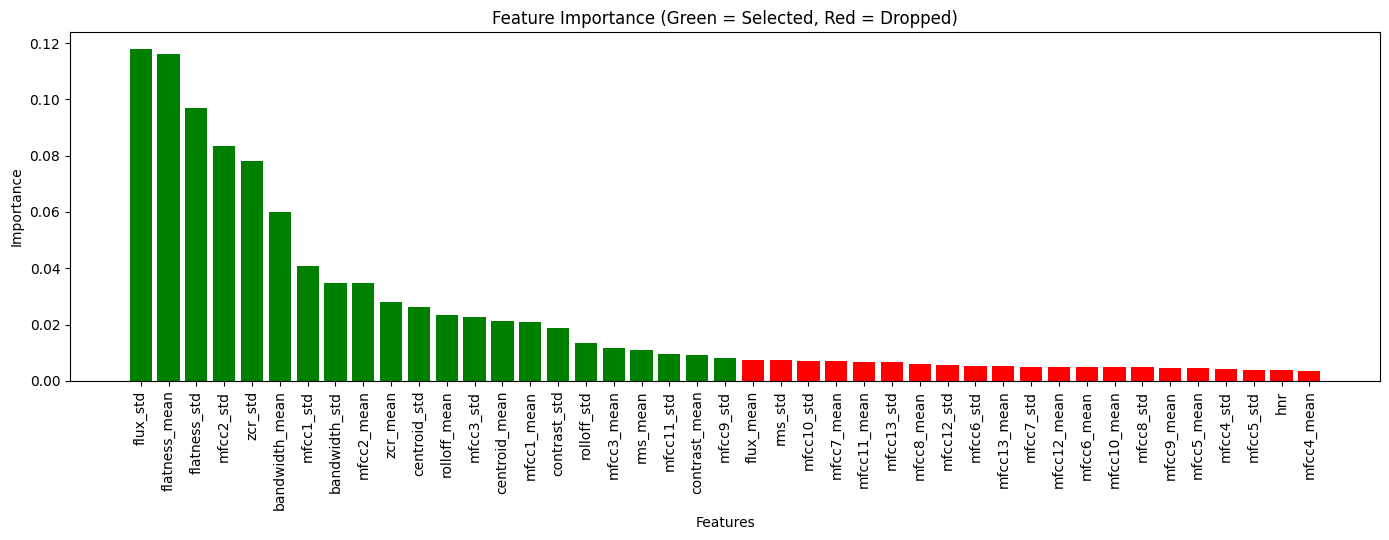

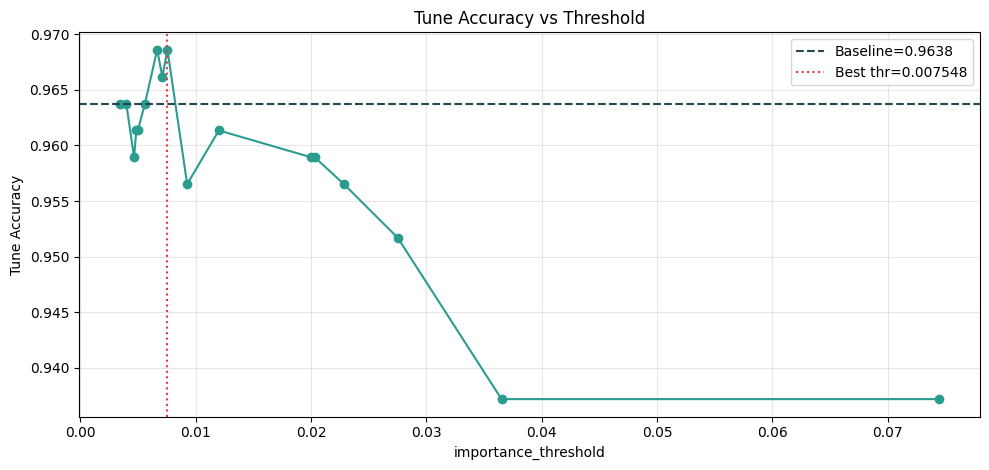

In [4]:
# 3) Feature threshold findes KUN på tune_set
model_tune = search.best_estimator_

# Fit på train_core, evaluer på tune_set
model_tune.fit(X_train_core, y_train_core)

importances = model_tune.feature_importances_
feature_names = X_train_core.columns

baseline_tune_pred = model_tune.predict(X_tune)
baseline_tune_acc = accuracy_score(y_tune, baseline_tune_pred)

q_values = np.linspace(0.0, 0.9, 16)
candidate_thresholds = sorted(set(np.quantile(importances, q_values).round(6).tolist() + [0.02]))

threshold_results = []

for thr in candidate_thresholds:
    kept = [
        feature
        for feature, importance in zip(feature_names, importances)
        if importance >= thr
    ]

    if len(kept) < 1:
        continue

    X_train_thr = X_train_core[kept]
    X_tune_thr = X_tune[kept]

    thr_model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(target_names),
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist",
        **search.best_params_
    )

    thr_model.fit(X_train_thr, y_train_core)
    thr_pred = thr_model.predict(X_tune_thr)
    thr_acc = accuracy_score(y_tune, thr_pred)

    threshold_results.append({
        "threshold": float(thr),
        "n_kept": int(len(kept)),
        "n_removed": int(len(feature_names) - len(kept)),
        "tune_acc": float(thr_acc),
    })

if not threshold_results:
    raise ValueError("Kunne ikke evaluere nogen threshold-kandidater.")

results_df = pd.DataFrame(threshold_results)
results_df["delta_vs_baseline"] = results_df["tune_acc"] - baseline_tune_acc

best_row = results_df.sort_values(
    ["tune_acc", "n_kept", "threshold"],
    ascending=[False, True, True]
).iloc[0]

importance_threshold = float(best_row["threshold"])

features_to_keep = [
    feature
    for feature, importance in zip(feature_names, importances)
    if importance >= importance_threshold
]

removed_features = [
    feature
    for feature, importance in zip(feature_names, importances)
    if importance < importance_threshold
]

print(f"Tune baseline accuracy (alle features): {baseline_tune_acc:.4f}")
print(f"Best tune accuracy: {best_row['tune_acc']:.4f} ({best_row['delta_vs_baseline']:+.4f})")
print(f"Selected threshold: {importance_threshold:.6f}")
print(f"Keeping {len(features_to_keep)} / {len(feature_names)} features")
print(f"Removed {len(removed_features)} features")

# Feature-importance barplot: grøn = beholdt, rød = fjernet
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
bar_colors = ["green" if f in features_to_keep else "red" for f in importance_series.index]

plt.figure(figsize=(14, 5.5))
plt.bar(importance_series.index, importance_series.values, color=bar_colors)
plt.xticks(rotation=90)
plt.title("Feature Importance (Green = Selected, Red = Dropped)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.8))
plot_df = results_df.sort_values('threshold')
plt.plot(plot_df['threshold'], plot_df['tune_acc'], marker='o', color='#2a9d8f')
plt.axhline(baseline_tune_acc, linestyle='--', color='#264653', label=f"Baseline={baseline_tune_acc:.4f}")
plt.axvline(importance_threshold, linestyle=':', color='#e63946', label=f"Best thr={importance_threshold:.6f}")
plt.title('Tune Accuracy vs Threshold')
plt.xlabel('importance_threshold')
plt.ylabel('Tune Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# 4) Final one-time test (kun én gang)
# Retrain på hele training-data (train_core + tune_set) med valgte features
X_train_full_reduced = X_all[features_to_keep].copy()
y_train_full = y_all_encoded.copy()

final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(target_names),
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    **search.best_params_
)

final_model.fit(X_train_full_reduced, y_train_full)

df_final_test = pd.read_csv(FINAL_TEST_PATH)
for col in irrelevant_cols:
    if col in df_final_test.columns:
        df_final_test = df_final_test.drop(columns=[col])

X_final_test = df_final_test.drop(columns=["target"])
y_final_test = df_final_test["target"]

unknown_test_labels = sorted(set(y_final_test.unique()) - set(class_mapping.keys()))
if unknown_test_labels:
    raise ValueError(f"Ukendte klasser i final test target: {unknown_test_labels}")

y_final_test_encoded = y_final_test.map(class_mapping).astype(int)
X_final_test = X_final_test.reindex(columns=X_all.columns, fill_value=0)
X_final_test_reduced = X_final_test[features_to_keep].copy()

y_final_pred = final_model.predict(X_final_test_reduced)
final_acc = accuracy_score(y_final_test_encoded, y_final_pred)

print('=' * 70)
print('FINAL ONE-TIME TEST RESULT')
print('=' * 70)
print(f"Features used: {len(features_to_keep)}")
print(f"Final test accuracy: {final_acc:.4f}")
print('\nClassification Report:')
print(classification_report(y_final_test_encoded, y_final_pred, target_names=target_names, digits=4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_final_test_encoded, y_final_pred))

FINAL ONE-TIME TEST RESULT
Features used: 22
Final test accuracy: 0.9650

Classification Report:
              precision    recall  f1-score   support

   BlueNoise     0.9333    0.9800    0.9561       100
  BrownNoise     0.9500    0.9500    0.9500       100
       Clean     0.9406    0.9500    0.9453       100
   PinkNoise     1.0000    1.0000    1.0000       100
 VioletNoise     0.9894    0.9300    0.9588       100
  WhiteNoise     0.9800    0.9800    0.9800       100

    accuracy                         0.9650       600
   macro avg     0.9655    0.9650    0.9650       600
weighted avg     0.9655    0.9650    0.9650       600


Confusion Matrix:
[[ 98   0   0   0   1   1]
 [  0  95   5   0   0   0]
 [  0   5  95   0   0   0]
 [  0   0   0 100   0   0]
 [  5   0   1   0  93   1]
 [  2   0   0   0   0  98]]
